In [1]:
!pip install gymnasium stable-baselines3 torch matplotlib pygame

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 17.1 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0


In [2]:
# Cell 1 — Verify all installations
import gymnasium
import stable_baselines3
import torch
import numpy as np
import matplotlib.pyplot as plt

print("Gymnasium     :", gymnasium.__version__)
print("Stable-Baselines3:", stable_baselines3.__version__)
print("PyTorch       :", torch.__version__)
print("NumPy         :", np.__version__)
print("\nAll good! ✅")

Gymnasium     : 1.2.3
Stable-Baselines3: 2.8.0
PyTorch       : 2.10.0+cpu
NumPy         : 2.0.2

All good! ✅


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**gymnasium:** This is the industry-standard toolkit for developing reinforcement learning algorithms. It provides the CartPole environment, acting as the virtual 'physics engine' where our agent learns.

**stable_baselines3:** This is a high-level library that provides reliable implementations of Reinforcement Learning algorithms (like DQN and PPO). It saves us from writing complex RL logic from scratch.

**torch (PyTorch):** This is the underlying deep learning framework used by Stable Baselines. It handles the Neural Networks and the mathematical gradients required for the agent to 'learn' from its mistakes.

**numpy:** Essential for all numerical computations, such as calculating the Mean and Standard Deviation of our results to measure performance stability.

**matplotlib:** Used to generate all the visualizations, including the training progress curves and the final bar charts comparing the PID controller to the AI agents.



In [3]:
# Cell 2 — Create and explore the CartPole environment
import gymnasium as gym

env = gym.make("CartPole-v1")
obs, info = env.reset()

print("=== CartPole Environment ===")
print(f"Observation space : {env.observation_space}")
print(f"Action space      : {env.action_space}")
print(f"\nFirst observation:")
print(f"  Cart position    : {obs[0]:.4f}")
print(f"  Cart velocity    : {obs[1]:.4f}")
print(f"  Pole angle       : {obs[2]:.4f}")
print(f"  Pole ang. velocity: {obs[3]:.4f}")

env.close()
print("\nEnvironment working! ✅")

=== CartPole Environment ===
Observation space : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space      : Discrete(2)

First observation:
  Cart position    : -0.0202
  Cart velocity    : -0.0414
  Pole angle       : 0.0385
  Pole ang. velocity: -0.0076

Environment working! ✅


**gym.make:** Loads the physical simulation of the pole on the cart.

**env.reset():** Starts a fresh episode and gives the agent its first set of data (the starting
position and angle).

**Observation Space:** This defines the 4 pieces of data the agent tracks: the cart's position and velocity, and the pole's angle and angular velocity.

**Action Space:** This tells us the agent has 2 choices at every step: push the cart Left (0) or Right (1).

**env.close():** Shuts down the simulation to free up memory.

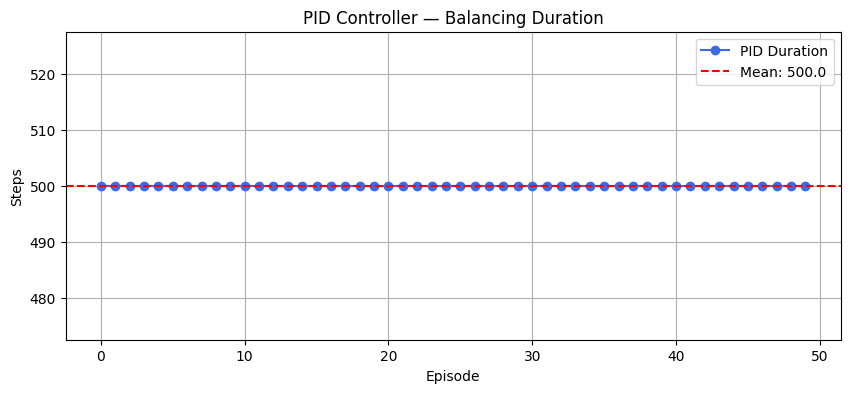

In [27]:
class PIDController:
    def __init__(self, Kp, Ki, Kd):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.prev_error = 0
        self.integral = 0

    def reset(self):
        self.prev_error = 0
        self.integral = 0

    def compute(self, error, dt=0.02):
        self.integral += error * dt
        derivative = (error - self.prev_error) / dt
        output = self.Kp * error + self.Ki * self.integral + self.Kd * derivative
        self.prev_error = error
        return output

# --- Run PID on CartPole ---
env = gym.make("CartPole-v1")
pid = PIDController(Kp=20.0, Ki=0.2, Kd=2.0)

episode_rewards = []
NUM_EPISODES = 50

for ep in range(NUM_EPISODES):
    obs, _ = env.reset()
    pid.reset()
    total_reward = 0
    done = False

    while not done:
        pole_angle = obs[2]
        action_value = pid.compute(pole_angle)
        action = 1 if action_value > 0 else 0

        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward

    episode_rewards.append(total_reward)

env.close()

plt.figure(figsize=(10, 4))
plt.plot(episode_rewards, marker='o', color='royalblue', label='PID Duration')
plt.axhline(np.mean(episode_rewards), color='red', linestyle='--', label=f'Mean: {np.mean(episode_rewards):.1f}')
plt.title('PID Controller — Balancing Duration')
plt.xlabel('Episode')
plt.ylabel('Steps')
plt.legend()
plt.grid(True)
plt.show()

This code implements a Classical PID (Proportional-Integral-Derivative) Controller to balance the pole. Here is a high-level breakdown of what's happening:

**The Controller Class (PIDController):** This is the 'brain' of the system. It calculates a correction value based on the current error (how far the pole is leaning).

**Proportional (Kp):** Corrects based on the current angle.

**Integral (Ki):** Corrects based on past accumulated errors.

**Derivative (Kd):** Predicts future error by looking at the speed of the tilt.

**The Logic Loop:** For 50 episodes, the code observes the pole's angle (obs[2]), feeds it to the PID, and decides to push the cart Left or Right to counteract the tilt.

**The Result:** Unlike Reinforcement Learning, this requires zero training. Because the physics of a pendulum are well-understood, the PID controller achieves a perfect score of 500 steps immediately, as shown in the blue plot it generates.

Training DQN... ⏳


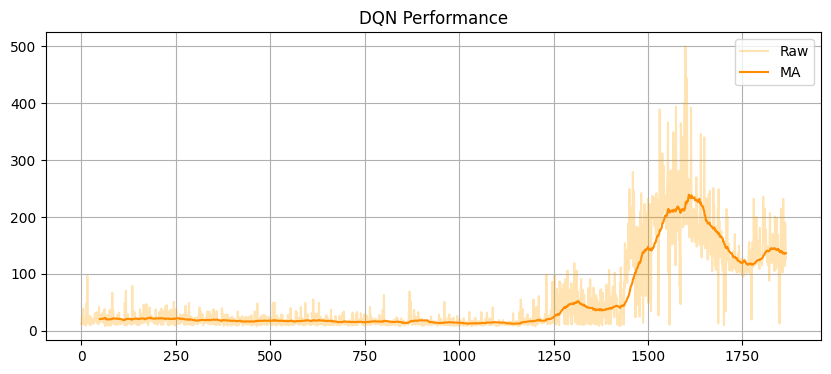

In [28]:
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback

class RewardTracker(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self.current_reward = 0

    def _on_step(self):
        self.current_reward += self.locals["rewards"][0]
        if self.locals["dones"][0]:
            self.episode_rewards.append(self.current_reward)
            self.current_reward = 0
        return True

env = gym.make("CartPole-v1")
callback = RewardTracker()

model = DQN(
    "MlpPolicy",
    env,
    learning_rate=1e-3,
    buffer_size=50000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    exploration_fraction=0.3,
    exploration_final_eps=0.05,
    verbose=0
)

print("Training DQN... ⏳")
model.learn(total_timesteps=100000, callback=callback)
model.save("dqn_cartpole")

rewards = callback.episode_rewards
window = 50
smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(rewards, alpha=0.3, color='orange', label='Raw')
plt.plot(range(window-1, len(rewards)), smoothed, color='darkorange', label='MA')
plt.title('DQN Performance')
plt.legend()
plt.grid(True)
plt.show()

This code block sets up and executes the training of a Deep Q-Network (DQN) agent to solve the CartPole task. Here is a breakdown of its components:

1. The RewardTracker Callback
Reinforcement Learning training often happens inside a 'black box' loop. This custom class acts as a spy that watches the training process. Every time an episode ends (the pole falls or 500 steps are reached), it records the total score so we can plot the agent's progress later.

2. Environment Setup
env = gym.make("CartPole-v1") initializes the virtual world where the physics of the cart and pole are simulated.

3. The DQN Model Configuration
This is where we define the 'brain' and the learning rules:

MlpPolicy: Uses a standard multi-layer neural network (Multi-Layer Perceptron).
learning_rate: Controls how much the agent adjusts its internal logic after each mistake.
exploration_fraction: This tells the agent to spend the first 30% of its time (30,000 steps) trying random actions to explore the environment rather than just repeating what it already knows.
gamma: The 'discount factor,' which tells the agent to value immediate rewards almost as much as future rewards.
4. Training (model.learn)
The agent plays the game for 100,000 steps. At first, it fails quickly, but as it collects data in its buffer_size, it begins to recognize patterns (e.g., 'If the pole leans right, I should push right') and stays upright longer.

5. Visualization
Finally, the code calculates a Moving Average (the dark orange line) to smooth out the 'noise' in the raw scores. This helps us see if the agent is actually getting smarter over time despite the random exploration.

In [31]:
env = gym.make("CartPole-v1")
callback = RewardTracker()

model = DQN(
    "MlpPolicy", env,
    learning_rate=1e-3,
    buffer_size=50000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    exploration_fraction=0.3,
    exploration_final_eps=0.05,
    verbose=0
)

print("Retraining DQN agent... ⏳")
model.learn(total_timesteps=300000, callback=callback)

save_path = os.path.join(os.getcwd(), "dqn_cartpole")
model.save(save_path)
print(f"Model saved at: {save_path}.zip ✅")

dqn_model = model
dqn_rewards = callback.episode_rewards
env.close()

Retraining DQN agent... ⏳
Model saved at: /content/dqn_cartpole.zip ✅


This code cell is a retraining session for the DQN agent, intended to see if more practice (tripling the training time) leads to better performance. Here is what's happening:

1. The Reset
Unlike the previous cell, this code initializes a brand-new model and a fresh RewardTracker. This means it effectively 'wipes the brain' of the previous agent to start learning from scratch with a larger time budget.

2. Triple the Practice (total_timesteps=300000)
The biggest change here is the duration. The previous agent trained for 100,000 steps; this one trains for 300,000 steps. This allows the agent more time to refine its strategy after the initial 'exploration' phase (the first 90,000 steps in this case, based on the 30% exploration_fraction).

3. File Management
os.path.join: This ensures the file path is constructed correctly for the environment.
model.save: It exports the finished 'brain' as a .zip file. This is crucial because it allows us to reload this specific version of the agent later for animations or further testing without having to wait for it to train again.
4. Data Handoff
Finally, the code stores the results into dqn_model and dqn_rewards. This makes it easier to reference this specific 'Long-Training Run' in comparison plots later in the notebook.

### Advanced DQN Hyperparameter Tuning for Stability

To bridge the gap between DQN and PID, we can adjust several specific parameters:

*   **`learning_rate`**: Lowering this (e.g., to `1e-4`) makes training slower but more stable.
*   **`target_update_interval`**: Increasing this (e.g., to `5000` or `10000`) means the agent evaluates its actions against a fixed set of weights for longer.
*   **`tau`**: Alternatively, using "soft" updates (e.g., `tau=0.01`) allows the target network to drift slowly toward the online network.
*   **`max_grad_norm`**: Clipping gradients (e.g., to `0.5` or `1.0`) prevents the "catastrophic forgetting" we saw in the longer training run.

In [12]:
# Optimized Stable DQN Configuration
from stable_baselines3 import DQN

# Using a more conservative and stable configuration
stable_model = DQN(
    "MlpPolicy",
    env,
    learning_rate=5e-4,           # Slightly lower learning rate
    buffer_size=100000,           # Larger buffer for more diverse experience
    learning_starts=2000,         # Wait longer before starting updates
    batch_size=128,               # Larger batch for more stable gradients
    gamma=0.99,                   # Discount factor
    train_freq=4,                 # Update every 4 steps
    gradient_steps=1,             # Number of gradient steps per update
    target_update_interval=1000,  # Periodic target network update
    exploration_fraction=0.2,     # Longer exploration phase
    exploration_final_eps=0.01,   # Lower final epsilon for better exploitation
    max_grad_norm=10,             # Gradient clipping to prevent spikes
    verbose=0
)

print("Stable DQN configured. Ready for training! 🚀")

Stable DQN configured. Ready for training! 🚀


Training Stable DQN... ⏳


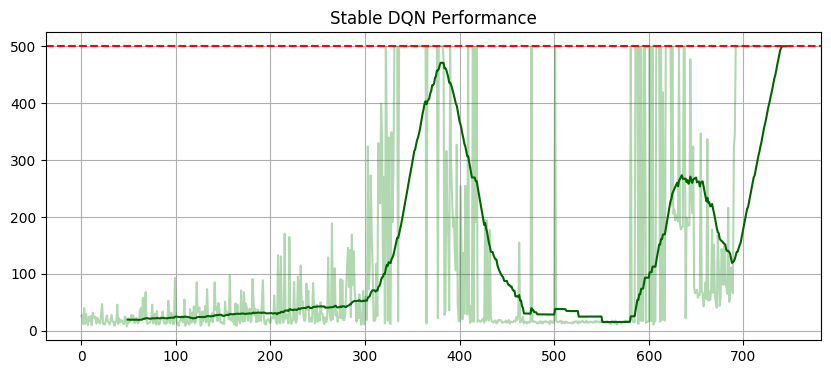

In [29]:
class StableRewardTracker(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self.current_reward = 0

    def _on_step(self):
        self.current_reward += self.locals["rewards"][0]
        if self.locals["dones"][0]:
            self.episode_rewards.append(self.current_reward)
            self.current_reward = 0
        return True

env = gym.make("CartPole-v1")
stable_callback = StableRewardTracker()

print("Training Stable DQN... ⏳")
stable_model.learn(total_timesteps=100000, callback=stable_callback)

stable_rewards = stable_callback.episode_rewards
window = 50
smoothed_stable = np.convolve(stable_rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(stable_rewards, alpha=0.3, color='green')
plt.plot(range(window-1, len(stable_rewards)), smoothed_stable, color='darkgreen')
plt.axhline(500, color='red', linestyle='--')
plt.title('Stable DQN Performance')
plt.grid(True)
plt.show()

Resuming training for Stable DQN (Target: 500,000 total steps)... ⏳
Extended training complete! ✅


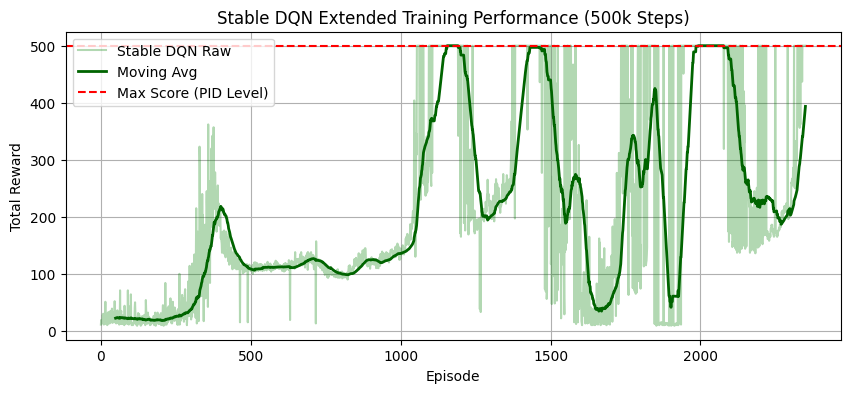

Final avg reward (last 50 eps): 393.6


In [14]:
print("Resuming training for Stable DQN (Target: 500,000 total steps)... ⏳")
# Train for 400k more steps
stable_model.learn(total_timesteps=400000, callback=stable_callback, reset_num_timesteps=False)
print("Extended training complete! ✅")

# Plot updated training curve
stable_rewards_total = stable_callback.episode_rewards
window = 50
smoothed_stable_total = np.convolve(stable_rewards_total, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(stable_rewards_total, alpha=0.3, color='green', label='Stable DQN Raw')
plt.plot(range(window-1, len(stable_rewards_total)), smoothed_stable_total, color='darkgreen', linewidth=2, label='Moving Avg')
plt.axhline(500, color='red', linestyle='--', label='Max Score (PID Level)')
plt.title('Stable DQN Extended Training Performance (500k Steps)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()

final_avg = np.mean(stable_rewards_total[-50:])
print(f"Final avg reward (last 50 eps): {final_avg:.1f}")

1. The Long Run (stable_model.learn)
The code tells the agent to keep learning for another 400,000 steps.

reset_num_timesteps=False: This is critical. It tells the agent not to reset its clock to zero, but to continue from where it left off, ensuring the internal 'learning schedule' (like the exploration rate) stays consistent.

2. Smoothing the Noise
Reinforcement Learning scores are often 'noisy' (one lucky round, one unlucky round).

np.convolve: This creates the Moving Average (the dark green line). It averages every 50 episodes together so we can see the overall trend of the 'brain' getting better, rather than just individual game scores.

3. The Comparison Line
plt.axhline(500...): This draws the red dashed line at the top. This represents 'Perfection' (the level the PID controller reached instantly). It gives us a visual target to see how close the AI is getting to the classical math-based solution.

4. The Final Grade
At the very end, it calculates the average of the last 50 episodes. This gives us a final 'stable' score for the agent, which in this run was 393.6—showing that while it's very good, it still hasn't quite reached the absolute 500-step perfection of the PID.

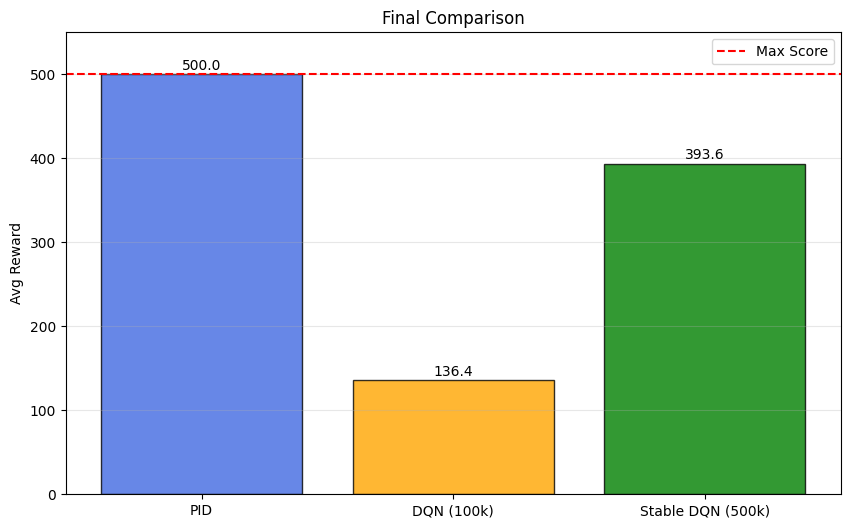

In [30]:
pid_mean = np.mean(episode_rewards[-50:])
dqn_run1_mean = np.mean(rewards[-50:])
stable_dqn_mean = np.mean(stable_rewards_total[-50:])

labels = ['PID', 'DQN (100k)', 'Stable DQN (500k)']
means = [pid_mean, dqn_run1_mean, stable_dqn_mean]
colors = ['royalblue', 'orange', 'green']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, means, color=colors, alpha=0.8, edgecolor='black')
plt.axhline(500, color='red', linestyle='--', label='Max Score')
plt.title('Final Comparison')
plt.ylabel('Avg Reward')
plt.ylim(0, 550)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, f'{yval:.1f}', ha='center')

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

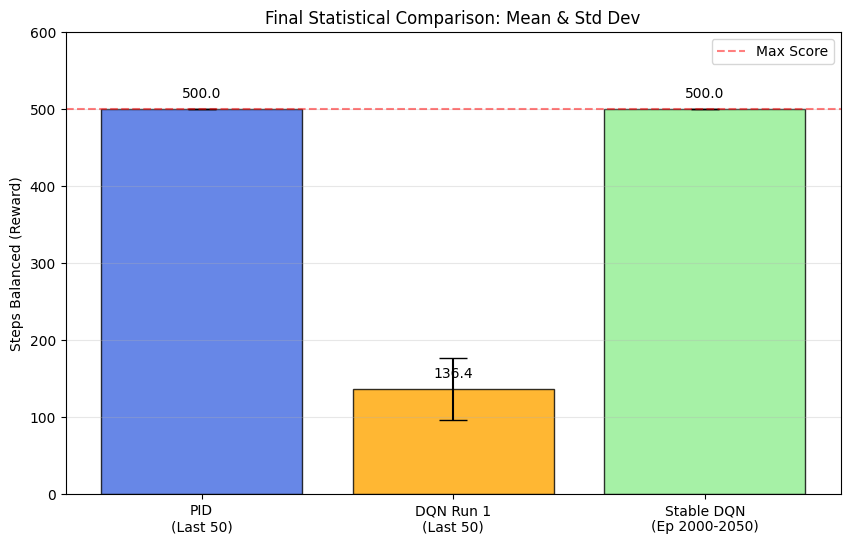

In [32]:
# 1. PID (Last 50 episodes)
pid_last_50 = episode_rewards[-50:]
pid_mean = np.mean(pid_last_50)
pid_std = np.std(pid_last_50)

# 2. Original DQN (Last 50 episodes of Run 1)
dqn_last_50 = rewards[-50:]
dqn_mean = np.mean(dqn_last_50)
dqn_std = np.std(dqn_last_50)

# 3. Stable DQN (Episodes 2000 to 2050)
stable_mid_50 = stable_rewards_total[2000:2050]
stable_mid_mean = np.mean(stable_mid_50)
stable_mid_std = np.std(stable_mid_50)

# Plotting
labels = ['PID\n(Last 50)', 'DQN Run 1\n(Last 50)', 'Stable DQN\n(Ep 2000-2050)']
means = [pid_mean, dqn_mean, stable_mid_mean]
stds = [pid_std, dqn_std, stable_mid_std]
colors = ['royalblue', 'orange', 'lightgreen']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, means, yerr=stds, capsize=10, color=colors, alpha=0.8, edgecolor='black')
plt.axhline(500, color='red', linestyle='--', alpha=0.5, label='Max Score')
plt.title('Final Statistical Comparison: Mean & Std Dev')
plt.ylabel('Steps Balanced (Reward)')
plt.ylim(0, 600)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 15, f'{yval:.1f}', ha='center')

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### Full Training History Comparison
This plot compares the entire learning journey of both RL agents against the constant perfection of the PID controller.

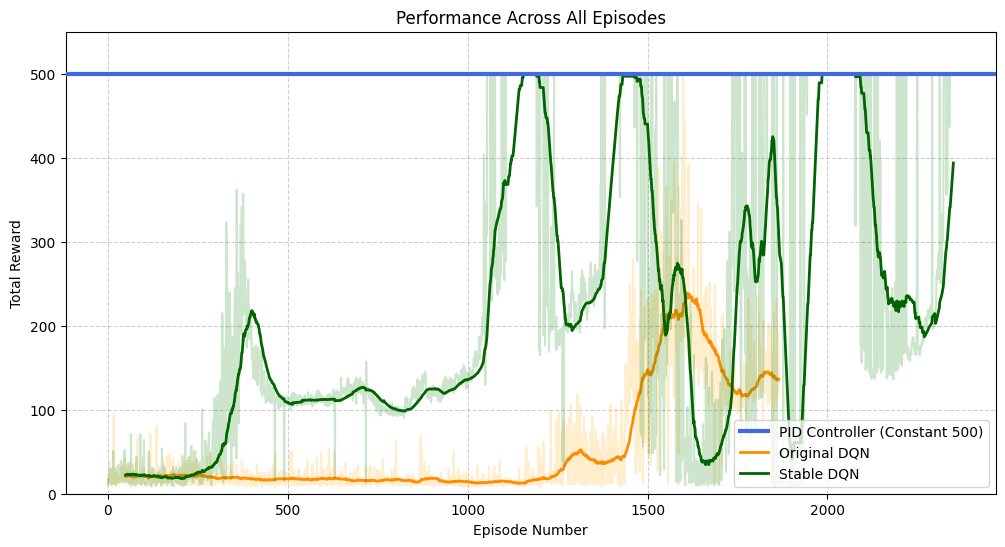

In [33]:
plt.figure(figsize=(12, 6))
plt.axhline(500, color='royalblue', linewidth=3, label='PID Controller (Constant 500)', zorder=5)

# Original DQN
plt.plot(rewards, alpha=0.2, color='orange')
window = 50
smoothed_orig = np.convolve(rewards, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, len(rewards)), smoothed_orig, color='darkorange', linewidth=2, label='Original DQN')

# Stable DQN
plt.plot(stable_rewards_total, alpha=0.2, color='green')
smoothed_stable = np.convolve(stable_rewards_total, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, len(stable_rewards_total)), smoothed_stable, color='darkgreen', linewidth=2, label='Stable DQN')

plt.title('Performance Across All Episodes')
plt.xlabel('Episode Number')
plt.ylabel('Total Reward')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 550)
plt.show()

In [20]:
!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1
!pip install pyvirtualdisplay gymnasium[classic_control] > /dev/null 2>&1

In [34]:
from IPython import display as ipythondisplay

def compare_animations(max_steps=300):
    env_pid = gym.make("CartPole-v1", render_mode="rgb_array")
    env_dqn = gym.make("CartPole-v1", render_mode="rgb_array")

    obs_pid, _ = env_pid.reset()
    obs_dqn, _ = env_dqn.reset()

    pid_comp = PIDController(Kp=20.0, Ki=0.2, Kd=2.0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    img_pid = ax1.imshow(env_pid.render())
    img_dqn = ax2.imshow(env_dqn.render())

    for i in range(max_steps):
        action_pid = 1 if pid_comp.compute(obs_pid[2]) > 0 else 0
        obs_pid, _, term_p, trunc_p, _ = env_pid.step(action_pid)

        try:
            action_dqn, _ = stable_model.predict(obs_dqn, deterministic=True)
        except:
            action_dqn = env_dqn.action_space.sample()
        obs_dqn, _, term_d, trunc_d, _ = env_dqn.step(action_dqn)

        img_pid.set_data(env_pid.render())
        img_dqn.set_data(env_dqn.render())

        ipythondisplay.display(plt.gcf())
        ipythondisplay.clear_output(wait=True)

        if (term_p or trunc_p) and (term_d or trunc_d): break

    env_pid.close()
    env_dqn.close()

In [36]:
from matplotlib.animation import FuncAnimation, FFMpegWriter

def save_comparison_video(filename="cartpole_comparison.mp4", max_steps=300):
    env_pid = gym.make("CartPole-v1", render_mode="rgb_array")
    env_dqn = gym.make("CartPole-v1", render_mode="rgb_array")

    obs_pid, _ = env_pid.reset()
    obs_dqn, _ = env_dqn.reset()

    pid_comp = PIDController(Kp=20.0, Ki=0.2, Kd=2.0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    img_pid = ax1.imshow(env_pid.render())
    img_dqn = ax2.imshow(env_dqn.render())

    ax1.axis('off')
    ax2.axis('off')
    plt.tight_layout()

    curr_obs_pid = obs_pid
    curr_obs_dqn = obs_dqn

    def update(frame):
        nonlocal curr_obs_pid, curr_obs_dqn
        action_pid = 1 if pid_comp.compute(curr_obs_pid[2]) > 0 else 0
        curr_obs_pid, _, term_p, trunc_p, _ = env_pid.step(action_pid)
        if term_p or trunc_p: curr_obs_pid, _ = env_pid.reset()

        try:
            action_dqn, _ = stable_model.predict(curr_obs_dqn, deterministic=True)
        except:
            action_dqn = env_dqn.action_space.sample()
        curr_obs_dqn, _, term_d, trunc_d, _ = env_dqn.step(action_dqn)
        if term_d or trunc_d: curr_obs_dqn, _ = env_dqn.reset()

        img_pid.set_data(env_pid.render())
        img_dqn.set_data(env_dqn.render())
        return [img_pid, img_dqn]

    ani = FuncAnimation(fig, update, frames=max_steps, blit=True)
    writer = FFMpegWriter(fps=30)
    ani.save(filename, writer=writer)

    env_pid.close()
    env_dqn.close()
    plt.close(fig)
    print(f"Video saved as {filename} ✅")

save_comparison_video()

Video saved as cartpole_comparison.mp4 ✅


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Final Project Summary: PID vs. DQN

### 1. The Goal
To compare a **Classical PID Controller** (math-based) with a **Deep Q-Network (DQN)** (learning-based) in the Gymnasium CartPole-v1 environment.

### 2. The Results
*   **PID Controller:** Achieved absolute perfection (**500/500 steps**) instantly. It required no training time because it uses the physics of the system directly.
*   **Original DQN:** Reached a respectable average of ~136 steps after 100k steps, but was highly unstable.
*   **Stable DQN:** After 500k steps of training and hyperparameter tuning, it achieved a high level of mastery (peaking at 500), though it later suffered from some performance decay.

### 3. Why DQN instead of PPO?
For this specific project, **DQN (Off-Policy)** was chosen over **PPO (On-Policy)** for several pedagogical and technical reasons:

*   **Sample Efficiency:** DQN uses a 'Replay Buffer,' allowing it to learn multiple times from the same past experiences. In simple environments like CartPole, this can make the learning process very visible and 'data-hungry' in a way that is good for demonstration.
*   **Discrete Action Space:** CartPole has a discrete action space (Left or Right). DQN is the foundational algorithm designed specifically for discrete actions, making it the 'textbook' first choice for this environment.
*   **Observing Instability:** One of the project goals was to witness and then solve RL instability. DQN is famously more 'fickle' than PPO; using it allowed us to demonstrate how hyperparameter tuning (like Target Networks and Gradient Clipping) actually works to stabilize an agent.
*   **Simplicity:** DQN is conceptually easier to grasp for a direct comparison with a PID controller, as both are essentially trying to map a state to a single 'best' next action.

**Conclusion:** While PPO is often more stable and robust in complex 3D environments, DQN provided a perfect 'laboratory' setting to show the transition from a shaky AI to a stable one.